# **Práctica de ETL**

# **1. Exploración y análisis inicial**

In [85]:
#Importing the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
#Loading the dataset
data=pd.read_csv("datasets/mall_dataset.csv")
#Mostrar las primeras filas del dataset
data.head(5)

,CustomerID,Genre,Age,Income_annual_k,Spending_Score_1_to_100
0,1,Male,19,15,39.0
1,2,Male,21,15,81.0
2,3,Female,20,16,6.0
3,4,Female,23,16,77.0
4,5,Female,31,17,40.0


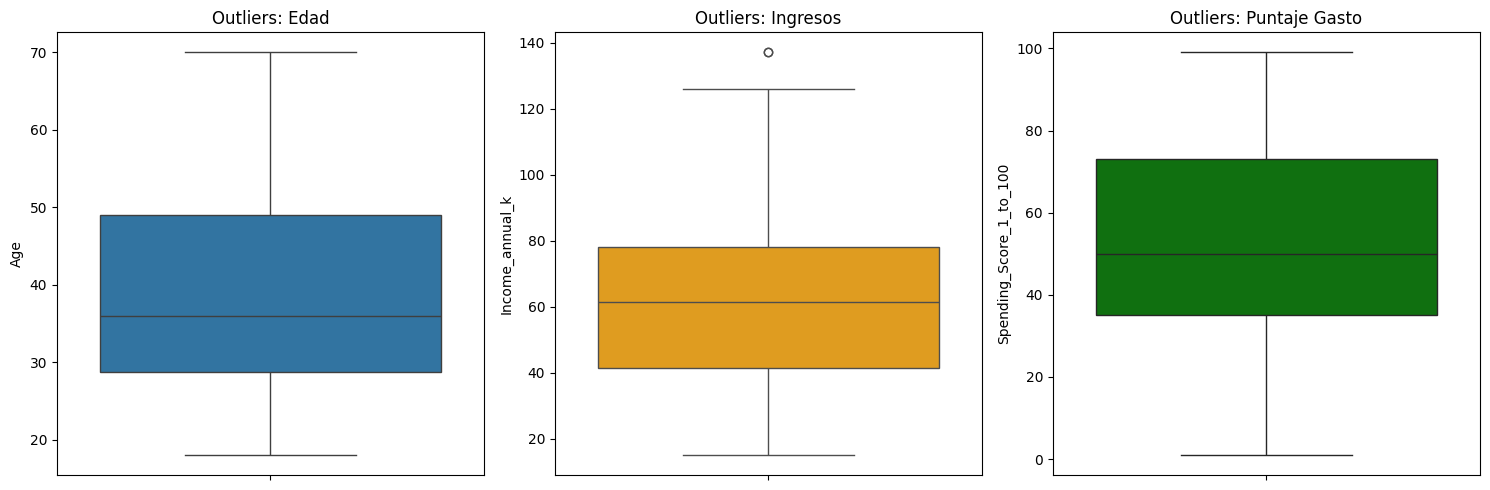

In [87]:
# Creamos una figura con 3 espacios
plt.figure(figsize=(15, 5))

# Boxplot para Edad
plt.subplot(1, 3, 1)
sns.boxplot(y=data['Age'])
plt.title('Outliers: Edad')

# Boxplot para Ingresos
plt.subplot(1, 3, 2)
sns.boxplot(y=data['Income_annual_k'], color='orange')
plt.title('Outliers: Ingresos')

# Boxplot para Puntaje de Gasto
plt.subplot(1, 3, 3)
sns.boxplot(y=data['Spending_Score_1_to_100'], color='green')
plt.title('Outliers: Puntaje Gasto')

plt.tight_layout()
plt.show()

In [88]:
#Data Cleaning

#Información del dataset
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CustomerID               200 non-null    int64  
 1   Genre                    197 non-null    str    
 2   Age                      200 non-null    int64  
 3   Income_annual_k          200 non-null    int64  
 4   Spending_Score_1_to_100  181 non-null    float64
dtypes: float64(1), int64(3), str(1)
memory usage: 7.9 KB


In [89]:
#Revisar los valores nulos
data.isnull().sum()

CustomerID                  0
Genre                       3
Age                         0
Income_annual_k             0
Spending_Score_1_to_100    19
dtype: int64

In [90]:
#Imputación al spending score, mediante la mediana, ya que es una variable numérica y no se ve afectada por los valores extremos
data["Spending_Score_1_to_100"]=data["Spending_Score_1_to_100"].fillna(data["Spending_Score_1_to_100"].median())
#Revisar los valores nulos después de la imputación
data.isnull().sum()

CustomerID                 0
Genre                      3
Age                        0
Income_annual_k            0
Spending_Score_1_to_100    0
dtype: int64

In [91]:
#Imputación a Genre, mediante la colocación de valor "Desconocido", ya que es una variable categórica y no se ve afectada por los valores extremos
data["Genre"]=data["Genre"].fillna("Desconocido")
#Revisar los valores nulos después de la imputación
data.isnull().sum()

CustomerID                 0
Genre                      0
Age                        0
Income_annual_k            0
Spending_Score_1_to_100    0
dtype: int64

In [92]:
# Unificar a inglés (o español, pero que sea consistente)
data['Genre'] = data['Genre'].replace({'femenino': 'Female', 'Male': 'Male', 'm': 'Male'})
# Verificar que ahora solo existan dos categorías únicas
print(data['Genre'].unique())

<StringArray>
['Male', 'Female', 'Desconocido']
Length: 3, dtype: str


In [93]:
# Ver quién es el que gana más de 130k
outlier_income = data[data['Income_annual_k'] > 130]
print(outlier_income)

     CustomerID   Genre  Age  Income_annual_k  Spending_Score_1_to_100
198         199  Female   32              137                     18.0
199         200    Male   30              137                     83.0


In [94]:
# Filtrar el dataframe para excluir los "Desconocido"
data = data[data['Genre'] != 'Desconocido']

# Verificar que ya no existan nulos
print(data.isnull().sum())

CustomerID                 0
Genre                      0
Age                        0
Income_annual_k            0
Spending_Score_1_to_100    0
dtype: int64


## **2. EDA básico**

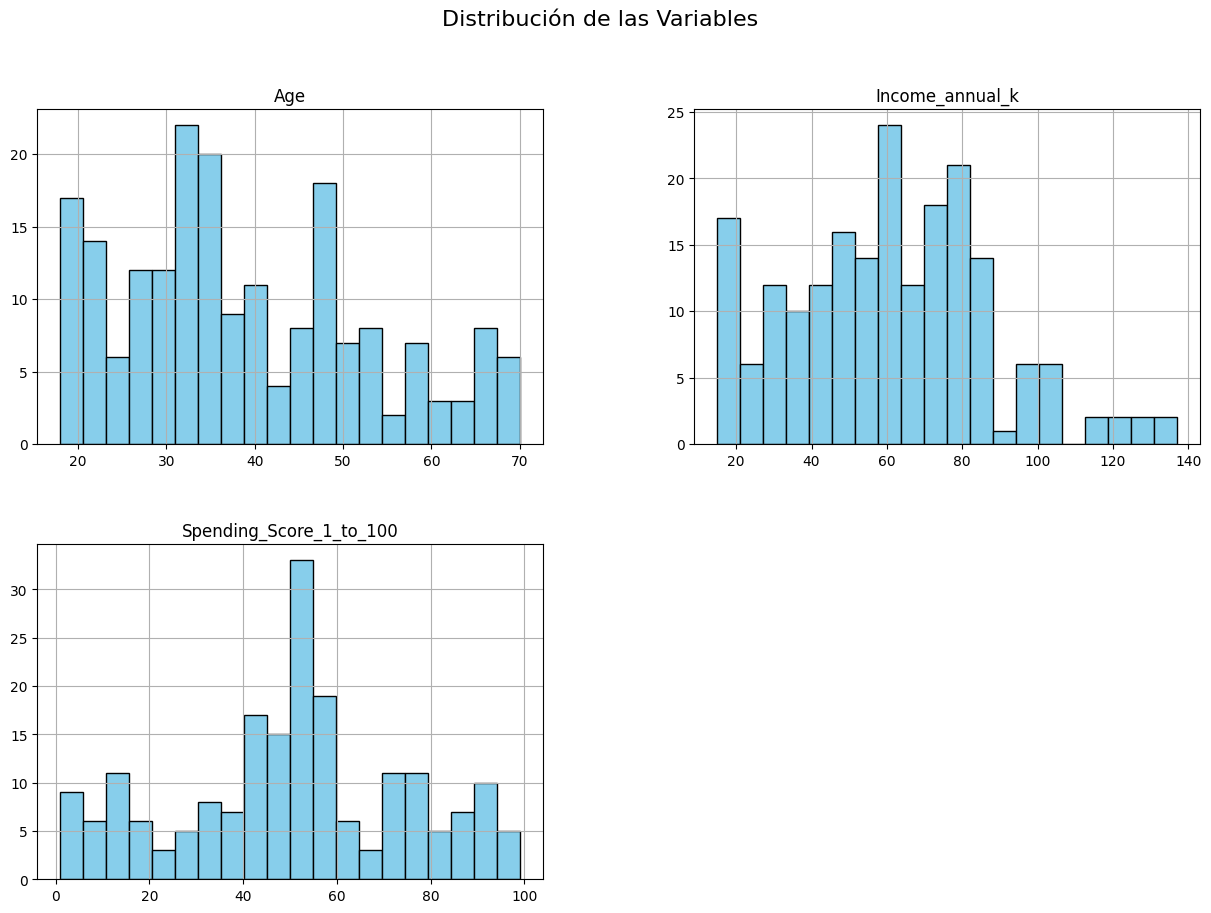

In [95]:
# Grafica histogramas y scatterplots para explorar la distribución de las variables.
# Ver la distribución de las 3 variables principales
data[['Age', 'Income_annual_k', 'Spending_Score_1_to_100']].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribución de las Variables", fontsize=16)
plt.show()

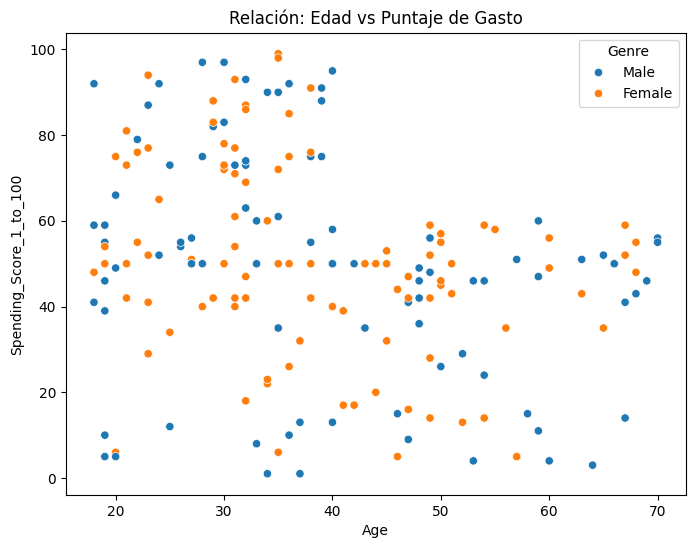

In [96]:
# Revisar las correlaciones entre las variables numéricas
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Age', y='Spending_Score_1_to_100', hue='Genre')
plt.title('Relación: Edad vs Puntaje de Gasto')
plt.show()

In [ ]:
# Convertir Male a 0 y Female a 1
data['Genre'] = data['Genre'].map({'Male': 0, 'Female': 1})

# Ver las primeras filas para confirmar
print(data.head())


   CustomerID  Genre  Age  Income_annual_k  Spending_Score_1_to_100
0           1      0   19               15                     39.0
1           2      0   21               15                     81.0
2           3      1   20               16                      6.0
3           4      1   23               16                     77.0
4           5      1   31               17                     40.0


,CustomerID,Genre,Age,Income_annual_k,Spending_Score_1_to_100
0,1,0,19,15,39.0
1,2,0,21,15,81.0
2,3,1,20,16,6.0
3,4,1,23,16,77.0
4,5,1,31,17,40.0
...,...,...,...,...,...
195,196,1,35,120,50.0
196,197,1,45,126,50.0
197,198,0,32,126,74.0
198,199,1,32,137,18.0


In [98]:
from sklearn.preprocessing import LabelEncoder

# 1. Empezamos de nuevo con los datos originales limpios de nulos generales
df_final = data.copy()
df_final = df_final.dropna() # Eliminamos cualquier nulo primero

# 2. Convertimos Género a números automáticamente
# No importa si dice 'Male', 'femenino', o 'M', esto le asignará un número
le = LabelEncoder()
df_final['Genre'] = le.fit_transform(df_final['Genre'].astype(str))

# 3. Quitamos el ID si existe
if 'CustomerID' in df_final.columns:
    df_final = df_final.drop(columns=['CustomerID'])

# 4. Forzamos que el resto de columnas sean números (por si hay algún string escondido)
for col in ['Age', 'Income_annual_k', 'Spending_Score_1_to_100']:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

# 5. Limpieza final por si acaso
df_final = df_final.dropna()

print(f"¡LOGRADO! Filas listas: {len(df_final)}")
print("Clases detectadas en Genre:", le.classes_) # Esto te dirá qué etiquetas encontró
print(df_final.head())

¡LOGRADO! Filas listas: 197
Clases detectadas en Genre: ['0' '1']
   Genre  Age  Income_annual_k  Spending_Score_1_to_100
0      0   19               15                     39.0
1      0   21               15                     81.0
2      1   20               16                      6.0
3      1   23               16                     77.0
4      1   31               17                     40.0


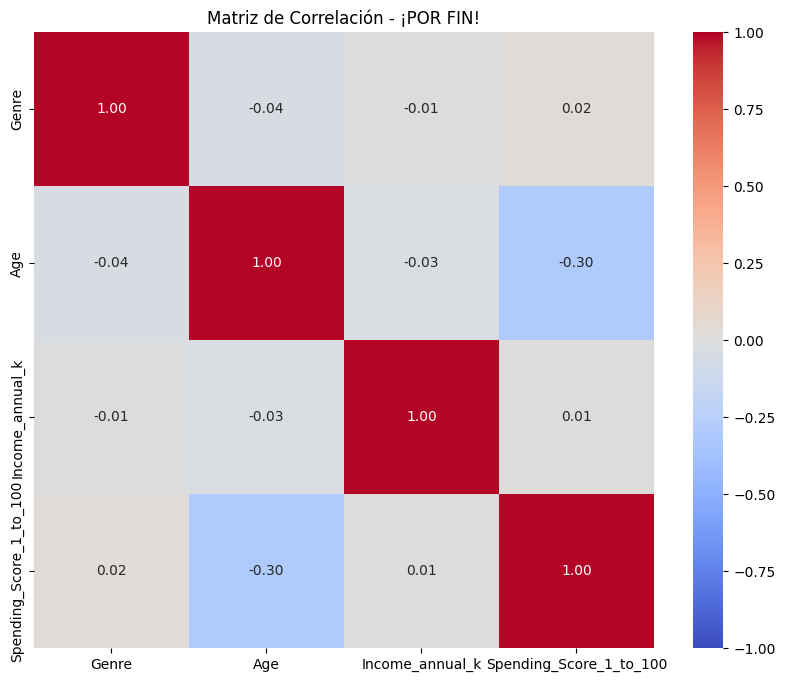

In [99]:
#Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación - ¡POR FIN!')
plt.show()

# **3. Procesamiento**

In [100]:
# Guardar el dataset limpio y numérico
df_final.to_csv('Mall_Customers_Clean.csv', index=False)
print("¡Archivo guardado exitosamente!")

¡Archivo guardado exitosamente!


In [101]:
from sklearn.preprocessing import StandardScaler

# Seleccionamos las columnas para el modelo
X = df_final[['Age', 'Income_annual_k', 'Spending_Score_1_to_100']]

# Aplicamos el escalado (Media = 0, Desviación Estándar = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Datos escalados listos para Machine Learning.")

Datos escalados listos para Machine Learning.


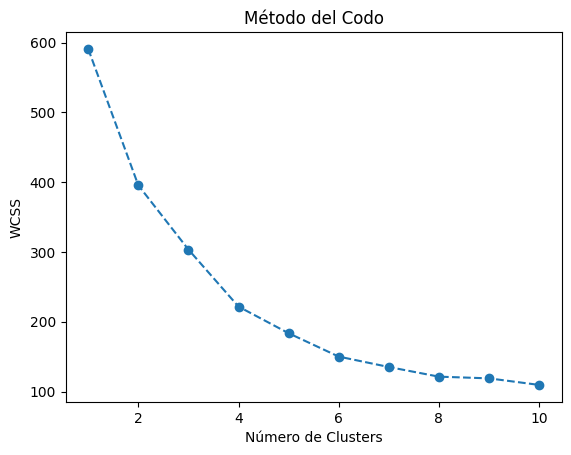

In [102]:
from sklearn.cluster import KMeans

wcss = [] # Within-Cluster Sum of Square
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

# **4. Feature engineering (crear nuevas variables)**

In [104]:
# Definimos los cortes de edad y las etiquetas
bins = [0, 18, 35, 60, 100]
labels = ['niño/adolescente', 'adulto joven', 'adulto', 'adulto mayor']

# Creamos la nueva variable
df_final['Edad_Grupo'] = pd.cut(df_final['Age'], bins=bins, labels=labels)

# Justificación: Esta variable es útil porque permite segmentar estrategias 
# de marketing diferenciadas por etapa de vida, no solo por años exactos.
print(df_final[['Age', 'Edad_Grupo']].head())

   Age    Edad_Grupo
0   19  adulto joven
1   21  adulto joven
2   20  adulto joven
3   23  adulto joven
4   31  adulto joven
